# 17 — What makes the suppressive component unique?

## Текущая картина механизма

Предыдущие причинные эксперименты показали, что успешное скрытие объекта определяется очень малой частью полной clean→patched дельты в Detect-input пространствах. Удаление oracle-компоненты восстанавливало все проверенные скрытые цели, но перенос одной этой компоненты воспроизводил скрытие не всегда: она необходима, однако действует во взаимодействии с остальной дельтой.

Для одного изображения без маски патча и без парного clean-входа мы оцениваем вклад координаты как `(activation − clean_population_mean) × gradient(person logit)`. Глобальные low-rank и row-space оценки не сработали; sign-selective top-negative координаты восстанавливают часть скрытых целей. Этот ноутбук проверяет более узкий вопрос: **какой структурой эта полезная отрицательная компонента отличается от обычного сигнала?**

В выборе кандидатов и вмешательства не используются target box, patch location или парное чистое изображение. Независимые clean-изображения нужны только для population baseline и калибровки gate; target annotation используется после инференса для оценки.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd()
if ROOT.name == 'CandidateRoutingAndAttackPath':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from CandidateRoutingAndAttackPath.component_uniqueness_analysis import (
    analyze_component_uniqueness, latest_complete_run,
)

RUN_DIR = analyze_component_uniqueness(latest_complete_run())
clusters = pd.read_csv(RUN_DIR / 'autonomous_cluster_rows.csv')
repairs = pd.read_csv(RUN_DIR / 'autonomous_repair_rows.csv')
uniqueness = pd.read_csv(RUN_DIR / 'component_uniqueness.csv')
gates = pd.read_csv(RUN_DIR / 'component_gate_evaluation.csv')
guarded = pd.read_csv(RUN_DIR / 'guarded_repair_evaluation.csv')
display(Markdown((RUN_DIR / 'component_uniqueness_report.md').read_text()))
print('Run:', RUN_DIR)

# What makes the suppressive component distinctive?

This analysis uses no paired clean image, patch mask, patch location, or target box for selection.
Clean images are an independent population reference and target annotations are used only after inference for evaluation.

## Component versus other candidate clusters in successful hides

- Hidden inputs: 49; target-cluster rows: 42.
- Strongest single distinction: `top_negative_1000_gain_concentration`, AUC=0.926, target direction=low.
- Reserve-tension ranking localizes the hidden target top-1 in 35/49 inputs (71.4%).

The consistent signature is a large candidate reserve under a diffuse, high-leverage negative tail: large total negative mass, low top-k concentration, and negative coordinates that benefit many reserve members.
The positive-coordinate fraction is nearly saturated and therefore does not distinguish the component.

## Clean-calibrated gate

- Primary score: `max_diffuse_negative_leverage` = negative mass × (1 − concentration) × gain/L2.
- Clean versus hidden AUC: 0.962.
- Conservative q99: held-out clean triggers 0/50; successful-hide triggers 27/49.
- Balanced q95: held-out clean triggers 2/50; successful-hide triggers 40/49.

## Guarded intervention

- Conservative q99 + top-1 k=1000 recovers 13/49 hidden targets; clean target detection=100.0%, clean full-output F1=1.000.
- Balanced q95 + top-1 k=1000 recovers 21/49 hidden targets; clean target detection=100.0%, clean full-output F1=0.994.

## Interpretation boundary

This is evidence for a distinctive functional signature, not yet a universal attack detector. The cohort uses one detector, class, patch family, and placement protocol; the clean-test confidence interval is still wide.


Run: /Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/followup_outputs/autonomous_negative_repair_e65f3cbbdea1c58c


## 1. Чем целевая подавляющая компонента отличается от остальных кластеров

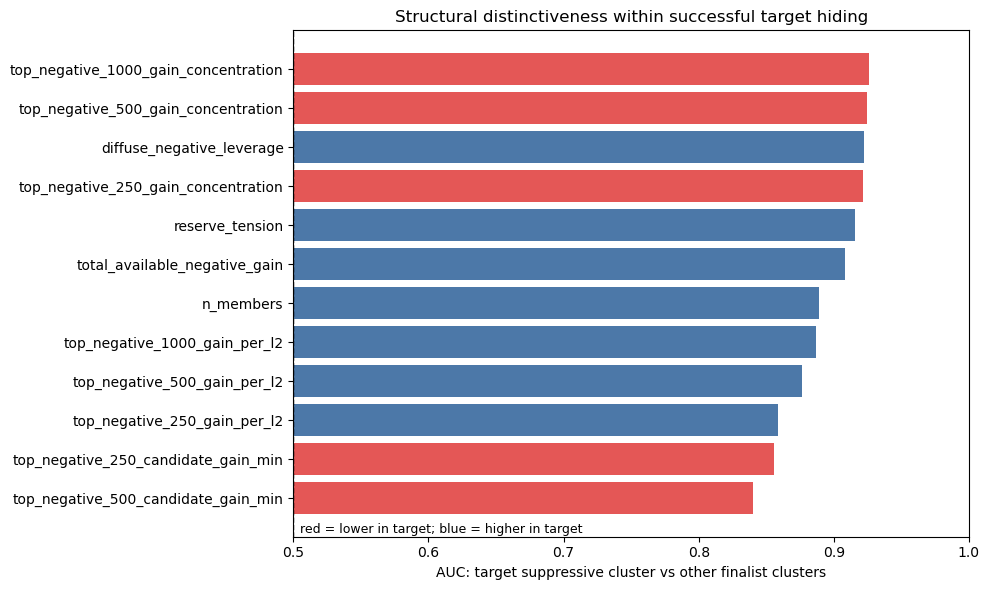

In [2]:
top = uniqueness.head(12).sort_values('discrimination_auc')
colors = ['#4C78A8' if d == 'high' else '#E45756' for d in top.target_direction]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top.metric, top.discrimination_auc, color=colors)
ax.axvline(0.5, color='black', ls='--', lw=1)
ax.set_xlim(0.5, 1.0)
ax.set_xlabel('AUC: target suppressive cluster vs other finalist clusters')
ax.set_title('Structural distinctiveness within successful target hiding')
ax.text(0.505, -0.9, 'red = lower in target; blue = higher in target', fontsize=9)
plt.tight_layout()
plt.show()

**Что видно.** Самый сильный отдельный признак — низкая `gain_concentration`: AUC около 0.93 при каждом $k$. Значит, подавление цели не сосредоточено в нескольких экстремальных координатах, а образует длинный отрицательный хвост. Одновременно у целевого кластера больше кандидатов, выше общая отрицательная масса и выше gain на единицу $L_2$. Простая величина `predicted_gain` слабее, поэтому компоненту отличает именно структура, а не только амплитуда.

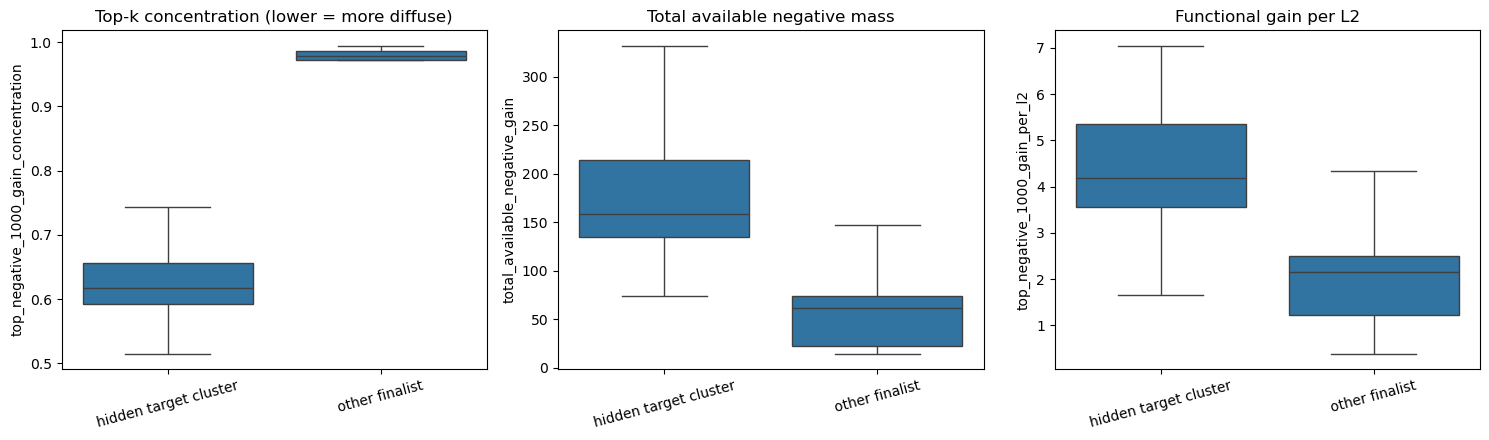

In [3]:
hidden_ids = set(repairs[(repairs.input_kind == 'patched') & (repairs.condition == 'observed') & repairs.source_hidden.astype(bool)].example_id.astype(str))
h = clusters[(clusters.input_kind == 'patched') & clusters.example_id.astype(str).isin(hidden_ids)].copy()
h['cluster'] = np.where(h.is_target_cluster.astype(bool), 'hidden target cluster', 'other finalist')
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.boxplot(data=h, x='cluster', y='top_negative_1000_gain_concentration', ax=axes[0], showfliers=False)
sns.boxplot(data=h, x='cluster', y='total_available_negative_gain', ax=axes[1], showfliers=False)
sns.boxplot(data=h, x='cluster', y='top_negative_1000_gain_per_l2', ax=axes[2], showfliers=False)
axes[0].set_title('Top-k concentration (lower = more diffuse)')
axes[1].set_title('Total available negative mass')
axes[2].set_title('Functional gain per L2')
for ax in axes:
    ax.tick_params(axis='x', rotation=15)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

**Что видно.** У компоненты скрытой цели медианная концентрация примерно 0.62 против 0.98 у прочих финалистов, отрицательная масса около 155 против 62, а gain/$L_2$ около 4.1 против 2.2. Это согласованная сигнатура: патч не просто создаёт сильный выброс, а дешёво в норме и распределённо давит целый резерв кандидатов одного объекта.

## 2. Можно ли заметить эту структуру без знания цели

Для каждого finalist-кластера строится единый mechanism-derived score:

$$S=\text{negative mass}\,(1-\text{top-k concentration})\,\frac{\text{predicted gain}}{\|\Delta\|_2}.$$

Для изображения берётся максимум $S$ по автоматически найденным кластерам. Порог задаётся только первой половиной clean-набора; вторая половина clean не участвует в калибровке.

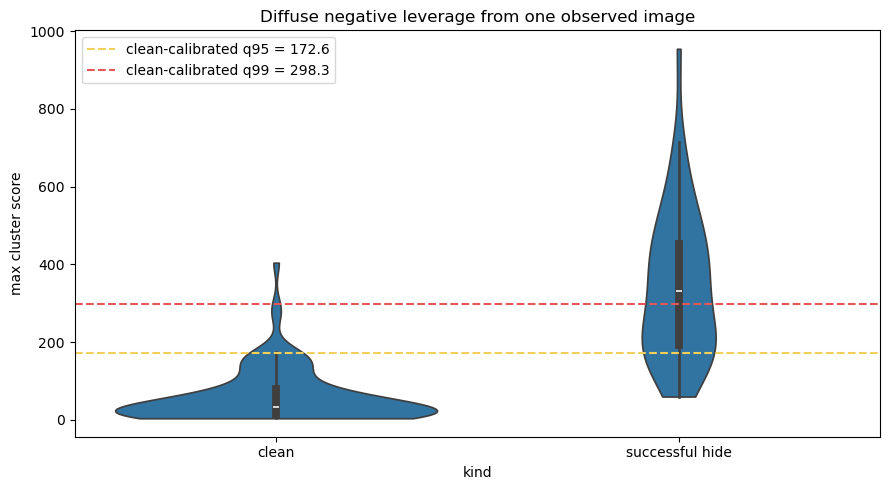

In [4]:
clusters['diffuse_negative_leverage'] = (clusters.total_available_negative_gain * (1 - clusters.top_negative_1000_gain_concentration) * clusters.top_negative_1000_gain_per_l2)
image_score = clusters.groupby(['input_kind', 'example_id'], as_index=False).diffuse_negative_leverage.max()
patched_groups = clusters[clusters.input_kind == 'patched'].groupby('example_id').analysis_group.first()
image_score['kind'] = image_score.input_kind
image_score.loc[(image_score.input_kind == 'patched') & image_score.example_id.astype(str).isin(hidden_ids), 'kind'] = 'successful hide'
plot_data = image_score[image_score.kind.isin(['clean', 'successful hide'])]
fig, ax = plt.subplots(figsize=(9, 5))
sns.violinplot(data=plot_data, x='kind', y='diffuse_negative_leverage', inner='box', cut=0, ax=ax)
for q, color in [(0.95, '#F2CF5B'), (0.99, '#E45756')]:
    threshold = gates[(gates.score == 'max_diffuse_negative_leverage') & np.isclose(gates.threshold_quantile, q)].threshold.iloc[0]
    ax.axhline(threshold, color=color, ls='--', label=f'clean-calibrated q{int(q*100)} = {threshold:.1f}')
ax.set_title('Diffuse negative leverage from one observed image')
ax.set_ylabel('max cluster score')
ax.legend()
plt.tight_layout()
plt.show()

**Что видно.** Распределения разделяются с AUC 0.962. Консервативный clean-q99 порог срабатывает на 27/49 успешных скрытий и на 0/50 отложенных clean; q95 — на 40/49 скрытий и 2/50 clean. Это первая найденная сигнатура, которая одновременно прямо следует из причинного наблюдения и вычисляется без target box, patch mask и clean-пары.

In [5]:
display(gates[gates.score == 'max_diffuse_negative_leverage'][[
    'threshold_quantile', 'threshold', 'clean_test_trigger_n',
    'clean_test_n', 'hidden_trigger_n', 'hidden_n', 'clean_vs_hidden_auc'
]].sort_values('threshold_quantile').style.format({
    'threshold': '{:.2f}', 'clean_vs_hidden_auc': '{:.3f}'
}))

,threshold_quantile,threshold,clean_test_trigger_n,clean_test_n,hidden_trigger_n,hidden_n,clean_vs_hidden_auc
7,0.950000,172.55,2,50,40,49,0.962
0,0.990000,298.32,0,50,27,49,0.962


## 3. Что происходит, если gate действительно управляет коррекцией

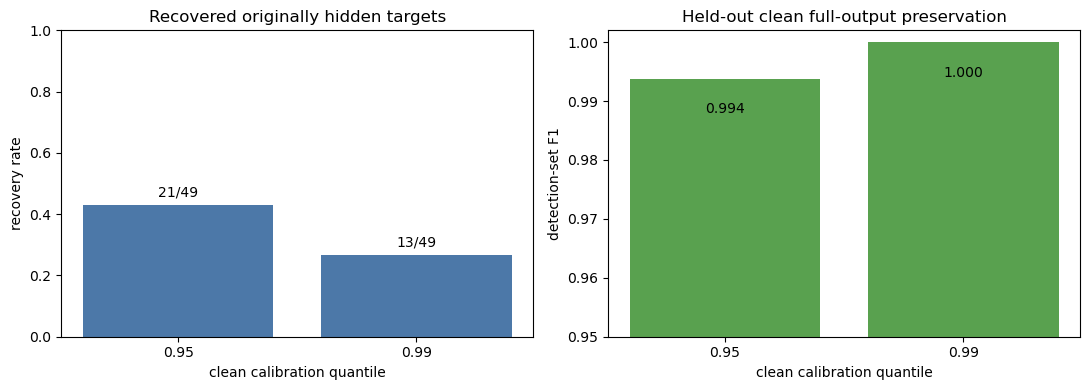

In [6]:
g = guarded[guarded.condition == 'top1_k1000'].sort_values('gate_quantile')
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(g.gate_quantile.astype(str), g.guarded_hidden_recovery_rate, color='#4C78A8')
axes[0].set_ylim(0, 1)
axes[0].set_title('Recovered originally hidden targets')
axes[0].set_xlabel('clean calibration quantile')
axes[0].set_ylabel('recovery rate')
for x, value, count in zip(range(len(g)), g.guarded_hidden_recovery_rate, g.guarded_hidden_recovery_n):
    axes[0].text(x, value + .03, f'{int(count)}/49', ha='center')
axes[1].bar(g.gate_quantile.astype(str), g.guarded_clean_detection_f1, color='#59A14F')
axes[1].set_ylim(0.95, 1.002)
axes[1].set_title('Held-out clean full-output preservation')
axes[1].set_xlabel('clean calibration quantile')
axes[1].set_ylabel('detection-set F1')
for x, value in zip(range(len(g)), g.guarded_clean_detection_f1):
    axes[1].text(x, value - .004, f'{value:.3f}', ha='center', va='top')
plt.tight_layout()
plt.show()

**Что видно.** Безопасный q99-gate восстанавливает 13/49 целей и не меняет ни одно из 50 отложенных clean-изображений. q95 восстанавливает 21/49; целевой человек сохраняется на всех clean, а F1 полного набора детекций равен 0.994. Ungated-коррекция восстанавливает 26/49, но снижает clean F1 до 0.954 — gate действительно убирает большую часть побочного ущерба.

## Вывод

Полезная компонента выделяется не пространственной геометрией патча и не одной огромной активацией. Её рабочая сигнатура — **диффузный, высокоэффективный отрицательный хвост, одновременно связанный с большим резервом кандидатов одного объекта**. Это уточняет прежнюю формулировку: патч скрывает человека, когда создаёт малую по размерности, но распределённую по координатам функциональную компоненту, которая совместно понижает score всего кандидатного резерва.

Результат уже даёт механизм-зависимый black-box-with-gradients gate, но ещё не универсальную защиту. Следующая обязательная проверка — другой patch seed/family, другие положения и масштабы, затем другой detector. Порог и формула должны быть заморожены до этих прогонов.